# XGBoost Baseline


## Setup

In [27]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "/Users/lin_/Solar_Prediction")   # so `src` is importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

from src.helper.data_preprocessing import load_all_zones

plt.rcParams["figure.figsize"] = (11, 4)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load data

In [28]:
# 12 raw NWP predictors (used as-is, no feature engineering)
NWP_VARS = ["VAR78","VAR79","VAR134","VAR157","VAR164","VAR165",
            "VAR166","VAR167","VAR169","VAR175","VAR178","VAR228"]

zones, df = load_all_zones(NWP_VARS)
df["POWER"] = df["POWER"].clip(0, 1)         # fix the lone 1.004 overshoot
df["ZONE"]  = df["ZONE"].astype("category")  # treat plant id as categorical, not numeric
df["hour"]  = df.ts.dt.hour                  # helper cols for the climatology baseline (not model features)
df["month"] = df.ts.dt.month

FEATURES = NWP_VARS + ["ZONE"]
TARGET   = "POWER"
print(df.shape, "|", len(FEATURES), "features")

(48183, 17) | 13 features


## 3. Train / validation / test split (time-based)

split train/test: 70/30

In [29]:
times = np.sort(df.ts.unique())
test_cut = times[int(len(times) * 0.70)]

trainval = df[df.ts <  test_cut]
test     = df[df.ts >= test_cut]

tv_times = np.sort(trainval.ts.unique())
val_cut  = tv_times[int(len(tv_times) * 0.85)]
train = trainval[trainval.ts <  val_cut]
val   = trainval[trainval.ts >= val_cut]

print(f"train: {train.shape[0]:>6}  (< {val_cut.astype('datetime64[D]')})")
print(f"val  : {val.shape[0]:>6}  ({val_cut.astype('datetime64[D]')} .. {test_cut.astype('datetime64[D]')})")
print(f"test : {test.shape[0]:>6}  (>= {test_cut.astype('datetime64[D]')})")

train:  28665  (< 2013-06-01)
val  :   5061  (2013-06-01 .. 2013-08-17)
test :  14457  (>= 2013-08-17)


## 4. Train XGBoost

In [30]:
model = xgb.XGBRegressor(
    n_estimators=2000, 
    learning_rate=0.02, 
    max_depth=5,
    subsample=0.8, 
    colsample_bytree=0.8, 
    min_child_weight=5, # how many sample one leaf to cover
    reg_lambda=1.0,     # L2
    objective="reg:squarederror", 
    eval_metric="rmse",
    early_stopping_rounds=5, 
    n_jobs=-1,  # CPU 
    random_state=42,
    enable_categorical=True,          # use pandas 'category' cols (ZONE) natively
)


model.fit(
    train[FEATURES], train[TARGET],
    eval_set=[(train[FEATURES], train[TARGET]), (val[FEATURES], val[TARGET])],
    verbose=50,
)
print("best_iteration:", model.best_iteration)

[0]	validation_0-rmse:0.27408	validation_1-rmse:0.22301
[50]	validation_0-rmse:0.15321	validation_1-rmse:0.12340
[100]	validation_0-rmse:0.11721	validation_1-rmse:0.10450
[150]	validation_0-rmse:0.10586	validation_1-rmse:0.10145
[200]	validation_0-rmse:0.10003	validation_1-rmse:0.10005
[250]	validation_0-rmse:0.09616	validation_1-rmse:0.09887
[300]	validation_0-rmse:0.09356	validation_1-rmse:0.09803
[348]	validation_0-rmse:0.09135	validation_1-rmse:0.09731
best_iteration: 343


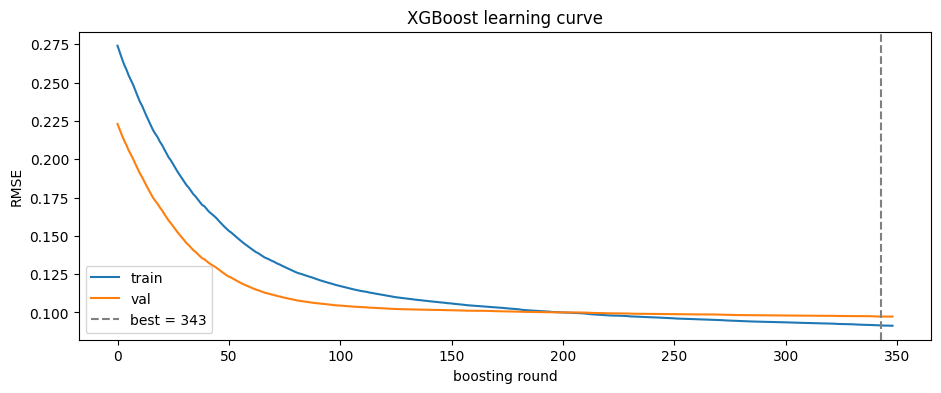

In [31]:
# Learning curve: train vs validation RMSE over boosting rounds
res = model.evals_result()
plt.plot(res["validation_0"]["rmse"], label="train")
plt.plot(res["validation_1"]["rmse"], label="val")
plt.axvline(model.best_iteration, ls="--", c="gray", label=f"best = {model.best_iteration}")
plt.xlabel("boosting round"); plt.ylabel("RMSE"); plt.legend()
plt.title("XGBoost learning curve"); plt.show()

## 5. Evaluate

Predictions clipped to `[0,1]`, compared against a **(zone, month, hour) climatology** baseline.

In [36]:
pred = np.clip(model.predict(test[FEATURES]), 0, 1)

# Climatology baseline: mean POWER per (zone, month, hour) learned on train
clim = train.groupby(["ZONE","month","hour"])[TARGET].mean()
base = (test.merge(clim.rename("clim"), on=["ZONE","month","hour"], how="left")["clim"]
            .fillna(train[TARGET].mean()).values)

rmse = root_mean_squared_error(test[TARGET], pred)
mae  = mean_absolute_error(test[TARGET], pred)
print(f"XGBoost      RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"Climatology  RMSE={root_mean_squared_error(test[TARGET], base):.4f}")
print(f"Improvement over climatology: {(1 - rmse/root_mean_squared_error(test[TARGET], base))*100:.1f}%\n")

test_ = test.assign(pred=pred)
print("Per-zone RMSE:")
print(test_.groupby("ZONE").apply(lambda g: root_mean_squared_error(g[TARGET], g["pred"])).round(4))

XGBoost      RMSE=0.1139  MAE=0.0672
Climatology  RMSE=0.1249
Improvement over climatology: 8.8%

Per-zone RMSE:
ZONE
1    0.1119
2    0.1149
3    0.1150
dtype: float64


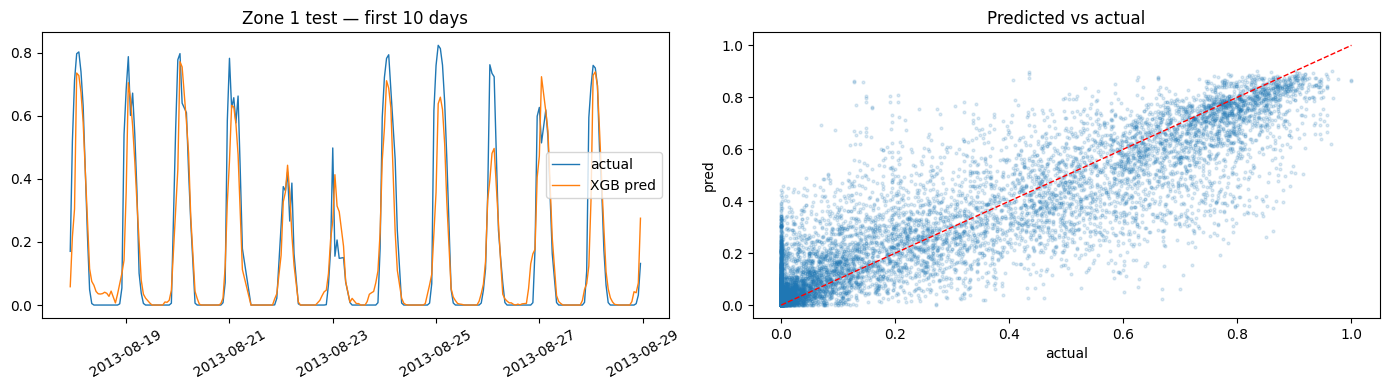

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# actual vs predicted, first 10 days of Zone 1 test
s = test_[test_.ZONE == 1].sort_values("ts").head(24*10)
ax[0].plot(s.ts, s[TARGET], label="actual", lw=1)
ax[0].plot(s.ts, s["pred"], label="XGB pred", lw=1)
ax[0].set_title("Zone 1 test — first 10 days"); ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)

# predicted vs actual scatter
ax[1].scatter(test_[TARGET], test_["pred"], s=4, alpha=0.15)
ax[1].plot([0,1],[0,1],"r--",lw=1); ax[1].set_xlabel("actual"); ax[1].set_ylabel("pred")
ax[1].set_title("Predicted vs actual")
plt.tight_layout(); plt.show()

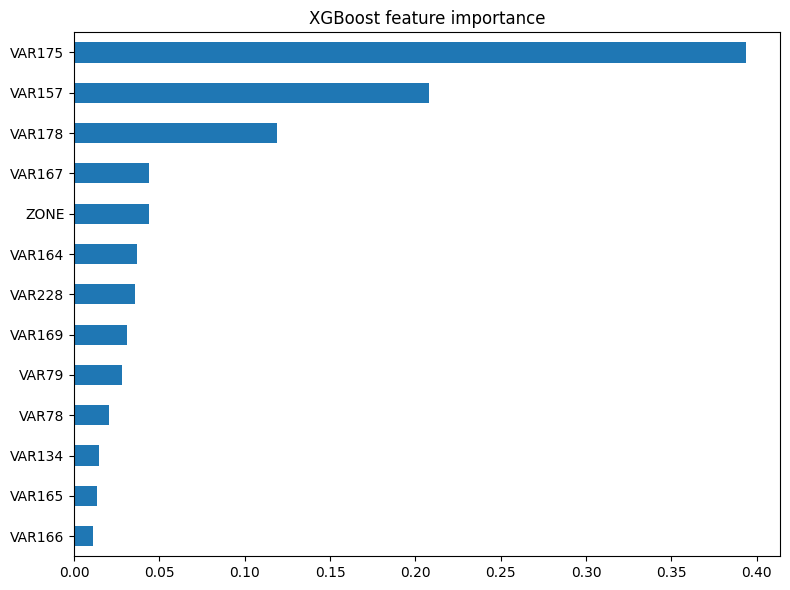

In [34]:
# Feature importance (gain)
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(figsize=(8, 6), title="XGBoost feature importance"); plt.tight_layout(); plt.show()

0:[VAR175<6181073] yes=1,no=2,missing=2
	1:[VAR157<57.8587036] yes=3,no=4,missing=4
		3:[VAR175<4519133] yes=7,no=8,missing=8
			7:[VAR164<0.691943765] yes=15,no=16,missing=16
				15:[VAR157<44.4989777] yes=31,no=32,missing=32
					31:leaf=0.0115998127
					32:leaf=0.0100151096
				16:[VAR79<0.0431697778] yes=33,no=34,missing=34
					33:leaf=0.00889896881
					34:leaf=0.00514417281
			8:[VAR167<291.581299] yes=17,no=18,missing=18
				17:[VAR175<5252643] yes=35,no=36,missing=36
					35:leaf=0.0064959717
					36:leaf=0.00340692746
				18:[VAR79<0.0358274281] yes=37,no=38,missing=38
					37:leaf=0.00860031508
					38:leaf=0.00529368268
		4:[VAR79<0.0431697778] yes=9,no=10,missing=10
			9:[VAR175<4168776] yes=19,no=20,missing=20
				19:[VAR78<0.0430259705] yes=39,no=40,missing=40
					39:leaf=0.008224844
					40:leaf=0.00473976834
				20:[VAR175<5462958] yes=41,no=42,missing=42
					41:leaf=0.00351526588
					42:leaf=0.00118924666
			10:[VAR164<0.972015381] yes=21,no=22,missing=22
				21:[

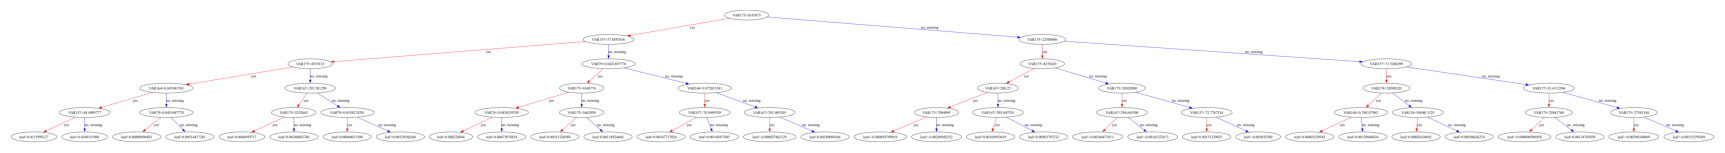

In [35]:
# Inspect one tree's split conditions
tree_idx = 0
booster  = model.get_booster()

# 1) Text rules (always works): "[feature<threshold] yes=.. no=.." ; leaf = output value
print(booster.get_dump(with_stats=False)[tree_idx])

# 2) Diagram (needs the graphviz 'dot' binary -> `brew install graphviz`)
try:
    fig, ax = plt.subplots(figsize=(22, 10))
    xgb.plot_tree(model, tree_idx=tree_idx, ax=ax); plt.show()
except Exception as e:
    print("plot_tree needs graphviz 'dot'. Install: brew install graphviz\n", e)